# Simulation Compute Method Analysis

This notebook analyzes the divergence between different compute methods (JavaScript, WebGPU, WebAssembly, WebWorkers) in the simulation framework.

## Metrics Used
1. **Pairwise Distance Matrix**: Spatial distribution of agents
2. **Distance Histograms**: Aggregate view of agent spacing
3. **Earth Mover's Distance (Wasserstein)**: Quantitative divergence measure
4. **Error Accumulation**: How divergence grows over time

## 1. Imports and Configuration

In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import pdist, squareform
from scipy.spatial.distance import pdist, squareform, euclidean
from fastdtw import fastdtw
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Paths
OUTPUT_DIR = Path('../tests/compute/outputs')
SIMULATIONS = ['boids', 'slime', 'gravity']

print('Imports loaded successfully!')

Imports loaded successfully!


## 2. Data Loading Functions

In [16]:
def load_position_data(simulation_name: str) -> Optional[dict]:
    """Load position data JSON for a given simulation."""
    path = OUTPUT_DIR / simulation_name / 'positions_data.json'
    if not path.exists():
        print(f'Warning: Position data not found at {path}')
        return None
    
    with open(path, 'r') as f:
        return json.load(f)


def extract_positions(data: dict, method: str, frame: int) -> np.ndarray:
    """Extract (x, y) positions for a given method and frame.
    
    Returns: np.ndarray of shape (num_agents, 2)
    """
    if method not in data['methods']:
        raise ValueError(f'Method {method} not found in data')
    
    method_data = data['methods'][method]
    if not method_data['available']:
        raise ValueError(f'Method {method} was not available during test')
    
    frame_data = method_data['frames'][frame]
    agents = frame_data['agents']
    
    # Sort agents by ID to ensure consistent order
    agents.sort(key=lambda x: x['id'])
    
    return np.array([[a['x'], a['y']] for a in agents])


def extract_velocities(data: dict, method: str, frame: int) -> np.ndarray:
    """Extract (vx, vy) velocities for a given method and frame.
    
    Returns: np.ndarray of shape (num_agents, 2)
    """
    method_data = data['methods'][method]
    frame_data = method_data['frames'][frame]
    agents = frame_data['agents']
    
    # Sort agents by ID to ensure consistent order
    agents.sort(key=lambda x: x['id'])
    
    return np.array([[a['vx'], a['vy']] for a in agents])


def get_available_methods(data: dict) -> List[str]:
    """Get list of methods that were available during testing."""
    return [m for m, info in data['methods'].items() if info['available']]


print('Data loading functions defined.')

Data loading functions defined.


## 3. Pairwise Distance Matrix Computation

In [17]:
def compute_pairwise_distances(positions: np.ndarray) -> np.ndarray:
    """Compute pairwise Euclidean distance matrix.
    
    Args:
        positions: np.ndarray of shape (num_agents, 2)
        
    Returns:
        np.ndarray: Condensed distance vector (upper triangle)
    """
    return pdist(positions, metric='euclidean')


def compute_distance_matrix_full(positions: np.ndarray) -> np.ndarray:
    """Compute full pairwise distance matrix.
    
    Returns:
        np.ndarray of shape (num_agents, num_agents)
    """
    return squareform(compute_pairwise_distances(positions))


def get_upper_triangle_distances(data: dict, method: str, frame: int) -> np.ndarray:
    """Get the upper triangle of pairwise distances for a method/frame."""
    positions = extract_positions(data, method, frame)
    return compute_pairwise_distances(positions)


print('Distance computation functions defined.')

Distance computation functions defined.


## 4. Histogram Analysis

In [18]:
def plot_distance_histograms(data: dict, frame: int, bins: int = 50, 
                              title_suffix: str = '') -> plt.Figure:
    """Plot overlaid histograms of pairwise distances for all methods."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    methods = get_available_methods(data)
    colors = plt.cm.tab10.colors
    
    for i, method in enumerate(methods):
        distances = get_upper_triangle_distances(data, method, frame)
        ax.hist(distances, bins=bins, alpha=0.4, label=method, 
                color=colors[i % len(colors)], density=True)
    
    ax.set_xlabel('Pairwise Distance')
    ax.set_ylabel('Density')
    ax.set_title(f'Pairwise Distance Distribution - Frame {frame} {title_suffix}')
    ax.legend()
    
    plt.tight_layout()
    return fig


def plot_distance_histogram_grid(data: dict, frames: List[int] = None, 
                                  bins: int = 50) -> plt.Figure:
    """Plot histogram grid for multiple frames."""
    if frames is None:
        frames = list(range(data['numFrames']))
    
    n_frames = len(frames)
    n_cols = min(3, n_frames)
    n_rows = (n_frames + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_frames == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    methods = get_available_methods(data)
    colors = plt.cm.tab10.colors
    
    for idx, frame in enumerate(frames):
        ax = axes[idx]
        for i, method in enumerate(methods):
            distances = get_upper_triangle_distances(data, method, frame)
            ax.hist(distances, bins=bins, alpha=0.4, label=method, 
                    color=colors[i % len(colors)], density=True)
        
        ax.set_xlabel('Distance')
        ax.set_ylabel('Density')
        ax.set_title(f'Frame {frame}')
        if idx == 0:
            ax.legend(fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(frames), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f"Pairwise Distance Distributions - {data['simulation']}", fontsize=14)
    plt.tight_layout()
    return fig


print('Histogram functions defined.')

Histogram functions defined.


## 5. Earth Mover's Distance (Wasserstein) Computation

In [19]:
def compute_emd_between_methods(data: dict, method1: str, method2: str, 
                                 frame: int) -> float:
    """Compute Earth Mover's Distance between two methods for a given frame.
    
    Uses 1D Wasserstein distance on the pairwise distance distributions.
    """
    distances1 = get_upper_triangle_distances(data, method1, frame)
    distances2 = get_upper_triangle_distances(data, method2, frame)
    
    return wasserstein_distance(distances1, distances2)


def compute_emd_matrix(data: dict, frame: int) -> pd.DataFrame:
    """Compute EMD between all pairs of methods for a given frame."""
    methods = get_available_methods(data)
    n = len(methods)
    
    matrix = np.zeros((n, n))
    
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            if i < j:
                emd = compute_emd_between_methods(data, m1, m2, frame)
                matrix[i, j] = emd
                matrix[j, i] = emd  # Symmetric
    
    return pd.DataFrame(matrix, index=methods, columns=methods)


def plot_emd_heatmap(data: dict, frame: int) -> plt.Figure:
    """Plot heatmap of EMD between all method pairs."""
    emd_matrix = compute_emd_matrix(data, frame)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(emd_matrix, annot=True, fmt='.6f', cmap='YlOrRd', 
                ax=ax, square=True)
    ax.set_title(f'EMD Between Methods - Frame {frame}')
    
    plt.tight_layout()
    return fig


print('EMD computation functions defined.')

EMD computation functions defined.


## 6. Error Accumulation Over Time

In [20]:
def compute_emd_over_time(data: dict, reference_method: str = 'JavaScript') -> pd.DataFrame:
    """Compute EMD against reference method for all frames.
    
    Returns:
        DataFrame with columns for each method, indexed by frame number
    """
    methods = get_available_methods(data)
    methods = [m for m in methods if m != reference_method]
    
    results = []
    for frame in range(data['numFrames']):
        row = {'frame': frame}
        for method in methods:
            row[method] = compute_emd_between_methods(data, reference_method, method, frame)
        results.append(row)
    
    return pd.DataFrame(results).set_index('frame')


def plot_emd_over_time(data: dict, reference_method: str = 'JavaScript') -> plt.Figure:
    """Plot EMD evolution over frames."""
    emd_df = compute_emd_over_time(data, reference_method)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for col in emd_df.columns:
        ax.plot(emd_df.index, emd_df[col], marker='o', linewidth=2, 
                markersize=6, label=f'{col} vs {reference_method}')
    
    ax.set_xlabel('Frame')
    ax.set_ylabel('Earth Mover\'s Distance')
    ax.set_title(f'Divergence Over Time - {data["simulation"]} (reference: {reference_method})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


print('Error accumulation functions defined.')

Error accumulation functions defined.


## 7a. DTW Analysis Functions

In [21]:
def get_agent_trajectory(data: dict, method: str, agent_idx: int) -> np.ndarray:
    """Extract full trajectory (T, 2) for a single agent."""
    trajectory = []
    # Assuming agents are always in the same order, but let's be safe and sort per frame
    # This is slow but correct. Optimization: extract all at once if needed.
    for frame in range(data['numFrames']):
        pos = extract_positions(data, method, frame)
        trajectory.append(pos[agent_idx])
    return np.array(trajectory)


def compute_dtw_analysis(data: dict, reference_method: str = 'JavaScript') -> pd.DataFrame:
    """Compute DTW distance for each agent between reference and other methods.
    
    Returns:
        DataFrame with per-agent DTW distances.
    """
    methods = get_available_methods(data)
    methods = [m for m in methods if m != reference_method]
    
    results = []
    num_agents = data['numAgents']
    
    print(f"Computing DTW for {num_agents} agents...")
    
    for method in methods:
        print(f"  Comparing {reference_method} vs {method}...")
        for agent_idx in range(num_agents):
            traj_ref = get_agent_trajectory(data, reference_method, agent_idx)
            traj_comp = get_agent_trajectory(data, method, agent_idx)
            
            # Compute DTW
            distance, path = fastdtw(traj_ref, traj_comp, dist=euclidean)
            
            results.append({
                'method': method,
                'agent_id': agent_idx,
                'dtw_distance': distance,
                'path_length': len(path)
            })
            
    return pd.DataFrame(results)


def plot_trajectory_comparison(data: dict, method: str, agent_idx: int, 
                               reference_method: str = 'JavaScript') -> plt.Figure:
    """Plot the trajectory of a specific agent for two methods."""
    traj_ref = get_agent_trajectory(data, reference_method, agent_idx)
    traj_comp = get_agent_trajectory(data, method, agent_idx)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot paths
    ax.plot(traj_ref[:, 0], traj_ref[:, 1], 'o-', label=f'{reference_method} (Ref)', 
            alpha=0.7, markersize=4)
    ax.plot(traj_comp[:, 0], traj_comp[:, 1], 'x--', label=f'{method}', 
            alpha=0.7, markersize=4)
    
    # mark start and end
    ax.scatter(traj_ref[0, 0], traj_ref[0, 1], c='g', s=100, label='Start')
    ax.scatter(traj_ref[-1, 0], traj_ref[-1, 1], c='r', s=100, label='End (Ref)')
    ax.scatter(traj_comp[-1, 0], traj_comp[-1, 1], c='orange', s=100, label=f'End ({method})')

    ax.set_title(f'Trajectory Comparison - Agent {agent_idx} ({method})')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.legend()
    ax.grid(True)
    
    return fig


def plot_dtw_distribution(dtw_df: pd.DataFrame) -> plt.Figure:
    """Plot distribution of DTW distances."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.histplot(data=dtw_df, x='dtw_distance', hue='method', kde=True, ax=ax)
    
    ax.set_title('Distribution of DTW Distances (Agent Trajectory Divergence)')
    ax.set_xlabel('DTW Distance')
    ax.set_ylabel('Count')
    
    return fig

print('DTW analysis functions defined.')


DTW analysis functions defined.


## 7. Additional Analysis

In [22]:
def compute_position_error(data: dict, method1: str, method2: str, 
                           frame: int) -> Dict[str, float]:
    """Compute direct position error between two methods.
    
    Returns dict with max, mean, std error.
    """
    pos1 = extract_positions(data, method1, frame)
    pos2 = extract_positions(data, method2, frame)
    
    errors = np.linalg.norm(pos1 - pos2, axis=1)
    
    return {
        'max': float(np.max(errors)),
        'mean': float(np.mean(errors)),
        'std': float(np.std(errors)),
        'median': float(np.median(errors))
    }


def compute_velocity_error(data: dict, method1: str, method2: str, 
                            frame: int) -> Dict[str, float]:
    """Compute velocity vector error between two methods."""
    vel1 = extract_velocities(data, method1, frame)
    vel2 = extract_velocities(data, method2, frame)
    
    errors = np.linalg.norm(vel1 - vel2, axis=1)
    
    return {
        'max': float(np.max(errors)),
        'mean': float(np.mean(errors)),
        'std': float(np.std(errors)),
        'median': float(np.median(errors))
    }


def compute_summary_statistics(data: dict, reference_method: str = 'JavaScript') -> pd.DataFrame:
    """Compute summary statistics for all methods across all frames."""
    methods = get_available_methods(data)
    methods = [m for m in methods if m != reference_method]
    
    results = []
    for method in methods:
        for frame in range(data['numFrames']):
            pos_err = compute_position_error(data, reference_method, method, frame)
            vel_err = compute_velocity_error(data, reference_method, method, frame)
            emd = compute_emd_between_methods(data, reference_method, method, frame)
            
            results.append({
                'method': method,
                'frame': frame,
                'pos_max_error': pos_err['max'],
                'pos_mean_error': pos_err['mean'],
                'vel_max_error': vel_err['max'],
                'vel_mean_error': vel_err['mean'],
                'emd': emd
            })
    
    return pd.DataFrame(results)


def plot_agent_positions(data: dict, frame: int, methods: List[str] = None) -> plt.Figure:
    """Scatter plot of agent positions for visual comparison."""
    if methods is None:
        methods = get_available_methods(data)
    
    n = len(methods)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, method in zip(axes, methods):
        pos = extract_positions(data, method, frame)
        ax.scatter(pos[:, 0], pos[:, 1], s=10, alpha=0.7)
        ax.set_xlim(0, data['width'])
        ax.set_ylim(0, data['height'])
        ax.set_title(f'{method}')
        ax.set_aspect('equal')
    
    plt.suptitle(f'Agent Positions - Frame {frame}', fontsize=14)
    plt.tight_layout()
    return fig


print('Additional analysis functions defined.')

Additional analysis functions defined.


---
# Analysis Execution

Run the cells below to perform analysis on your simulation data.

## Load Data

In [23]:
# Select simulation
SIMULATION = 'slime'
data = load_position_data(SIMULATION)

if data:
    print(f"Simulation: {data['simulation']}")
    print(f"Frames: {data['numFrames']}")
    print(f"Agents: {data['numAgents']}")
    print(f"Dimensions: {data['width']} x {data['height']}")
    print(f"Available methods: {get_available_methods(data)}")

Simulation: slime
Frames: 100
Agents: 500
Dimensions: 600 x 600
Available methods: ['JavaScript', 'WebAssembly', 'WebWorkers', 'WebGPU']


## Pairwise Distance Distribution

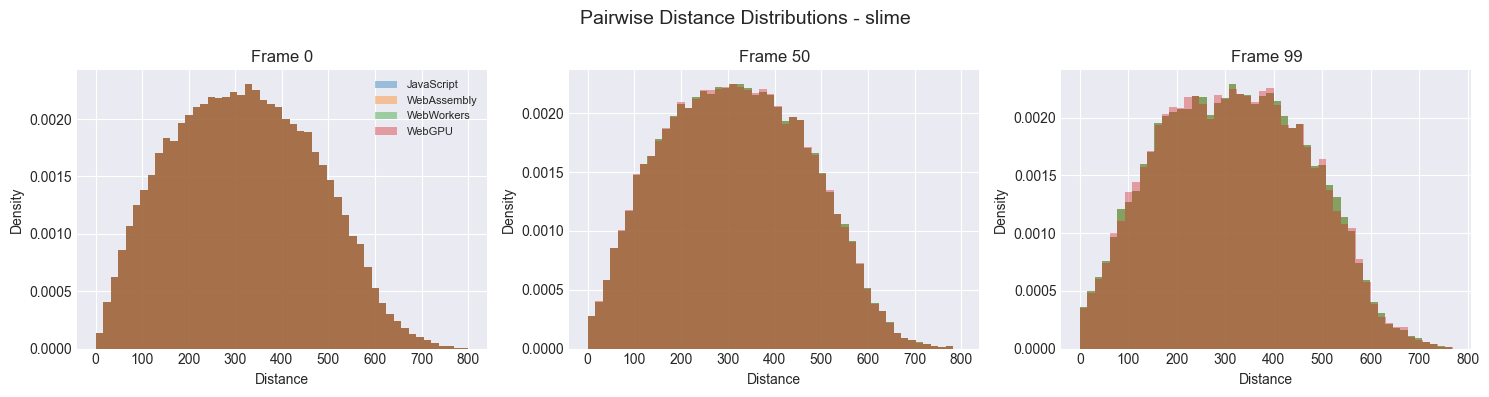

In [24]:
# Plot histogram grid for start, middle, end frames
if data:
    n_frames = data['numFrames']
    frames_to_plot = [0, n_frames//2, n_frames-1]
    fig = plot_distance_histogram_grid(data, frames=frames_to_plot)
    plt.show()

## Earth Mover's Distance (EMD) Analysis

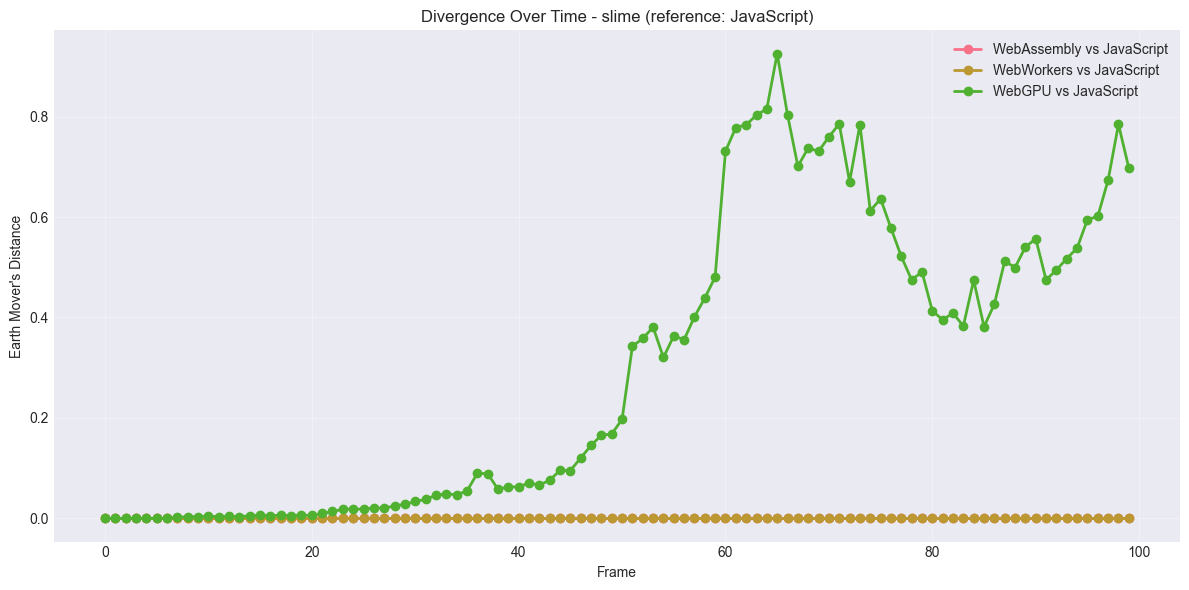

In [25]:
# Compute and plot EMD over time
if data:
    fig = plot_emd_over_time(data, reference_method='JavaScript')
    plt.show()

## Summary Statistics

In [26]:
if data:
    summary = compute_summary_statistics(data)
    # Show summary for the final frame
    final_frame_summary = summary[summary['frame'] == data['numFrames']-1]
    display(final_frame_summary[['method', 'pos_max_error', 'emd']])
    
    # Show overall aggregates
    print("\nOverall EMD Statistics:")
    display(summary.groupby('method')['emd'].describe())

,method,pos_max_error,emd
99,WebAssembly,0.000000,0.000000
199,WebWorkers,0.000000,0.000000
299,WebGPU,589.583567,0.697918



Overall EMD Statistics:


,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
WebAssembly,100.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
WebGPU,100.0,0.300003,0.291256,0.0,0.018462,0.182544,0.525694,0.925444
WebWorkers,100.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


## DTW Analysis Execution

Computing DTW for 500 agents...
  Comparing JavaScript vs WebAssembly...
  Comparing JavaScript vs WebWorkers...
  Comparing JavaScript vs WebGPU...


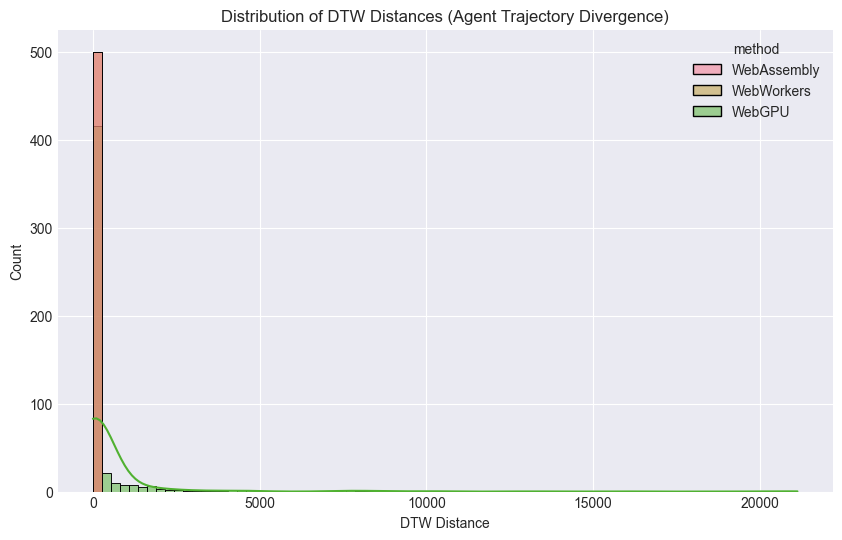


Worst diverted agent: 252 (WebGPU)
DTW Distance: 21126.47


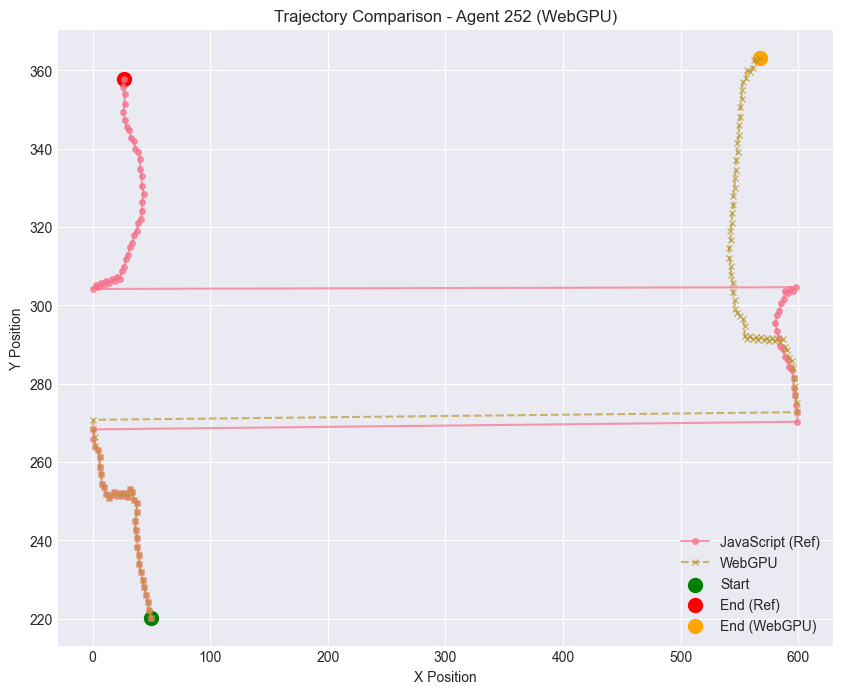

In [27]:
if data:
    # Compute DTW
    dtw_results = compute_dtw_analysis(data)
    
    # Plot Distribution
    fig_dist = plot_dtw_distribution(dtw_results)
    plt.show()
    
    # Find worst agent
    worst_agent = dtw_results.loc[dtw_results['dtw_distance'].idxmax()]
    print(f"\nWorst diverted agent: {worst_agent['agent_id']} ({worst_agent['method']})")
    print(f"DTW Distance: {worst_agent['dtw_distance']:.2f}")
    
    # Plot worst trajectory
    fig_traj = plot_trajectory_comparison(data, worst_agent['method'], 
                                          int(worst_agent['agent_id']))
    plt.show()